In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [4]:
df = pd.read_csv('pima_diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [32]:
df.shape

(768, 9)

In [5]:
df = df.drop_duplicates()
cols = ['Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI' ]
for col in cols:
  df[col] = df[col].replace(0, np.nan)
  df[col].fillna(df[col].median(), inplace = True)

In [6]:
X = df.drop('Outcome',  axis = 1 )
y = df['Outcome']

selector = SelectKBest(score_func = f_classif, k = 5)
X_new = selector.fit_transform(X,y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

X = df[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Selected Features: Index(['Pregnancies', 'Glucose', 'SkinThickness', 'BMI', 'Age'], dtype='object')


In [7]:
log_model = LogisticRegression (max_iter = 1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test, y_pred_log)

print("\nLogistic Regression Accuracy:", log_acc)
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

cv_scores = cross_val_score(log_model, X_train_scaled, y_train, cv = 5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

y_pred_lin = lin_model.predict(X_test_scaled)
y_pred_lin_binary = [1 if i > 0.5 else 0 for i in y_pred_lin]

lin_acc = accuracy_score(y_test, y_pred_lin_binary)
print("\nLinear Regression Accuracy:", lin_acc)





Logistic Regression Accuracy: 0.7532467532467533
[[81 18]
 [20 35]]
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154


Cross Validation Scores: [0.7398374  0.81300813 0.76422764 0.74796748 0.78688525]
Mean CV Accuracy: 0.7703851792616286

Linear Regression Accuracy: 0.7662337662337663


In [8]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _= roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

y_prob_lin = lin_model.predict(X_test_scaled)
fpr_lin, tpr_lin, _= roc_curve(y_test, y_prob_lin)
auc_lin = auc(fpr_lin, tpr_lin)

print("\nAUC Logistic:", auc_log)
print("AUC Linear:", auc_lin)


AUC Logistic: 0.8165289256198347
AUC Linear: 0.8183654729109274


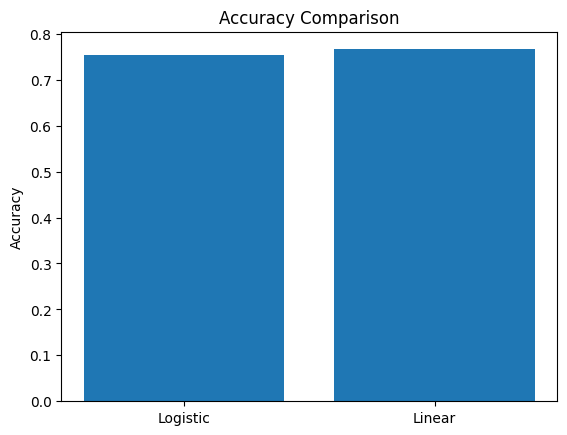

In [9]:
# Accuracy Comparison

plt.figure()
plt.bar(['Logistic', 'Linear'], [log_acc, lin_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

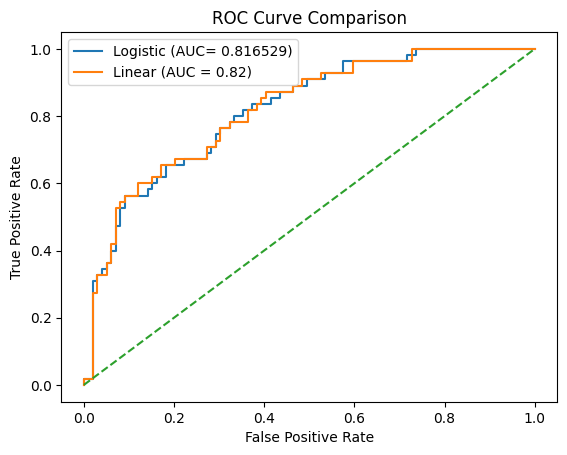


Sample Prediction: Diabetic


In [31]:
# ROC Curve

plt.figure()
plt.plot(fpr_log, tpr_log, label= f"Logistic (AUC= {auc_log :2f})")
plt.plot(fpr_lin, tpr_lin, label = f"Linear (AUC = {auc_lin:.2f})")
plt.plot([0,1], [0,1], linestyle = '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

def predict_diabetes(input_data):
  input_data = np.array(input_data).reshape(1, -1)
  input_data = scaler.transform(input_data)

  prediction = log_model.predict(input_data)
  return "Diabetic" if prediction[0] == 1 else "Not Diabetic"

# example

sample = X.iloc[0].values
print("\nSample Prediction:", predict_diabetes(sample))

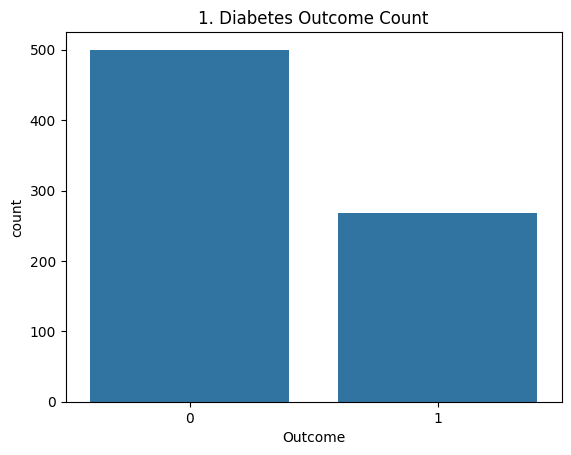

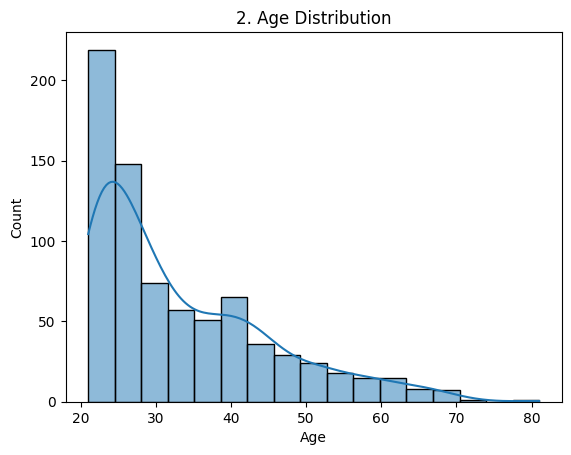

In [11]:
# 1. Target Distribution
sns.countplot(x='Outcome', data=df)
plt.title("1. Diabetes Outcome Count")
plt.show()


# 2. Age Distribution
sns.histplot(df['Age'], kde=True)
plt.title("2. Age Distribution")
plt.show()

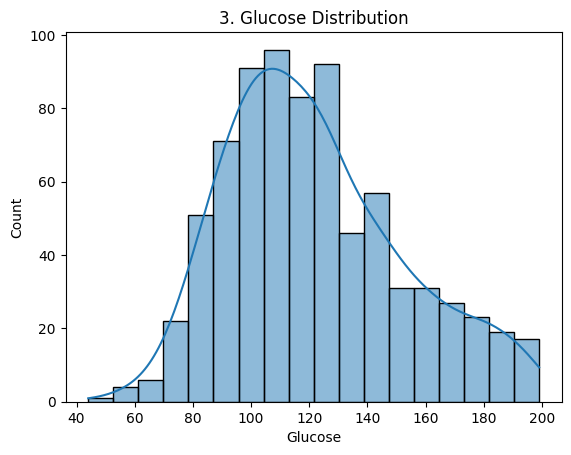

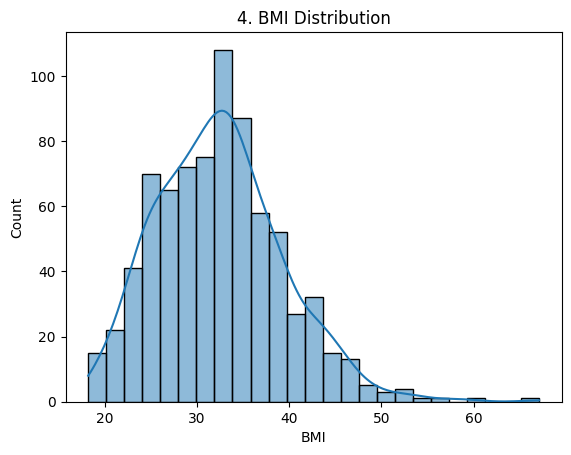

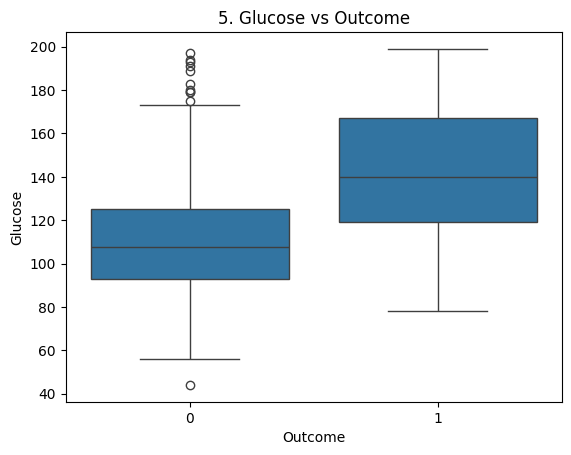

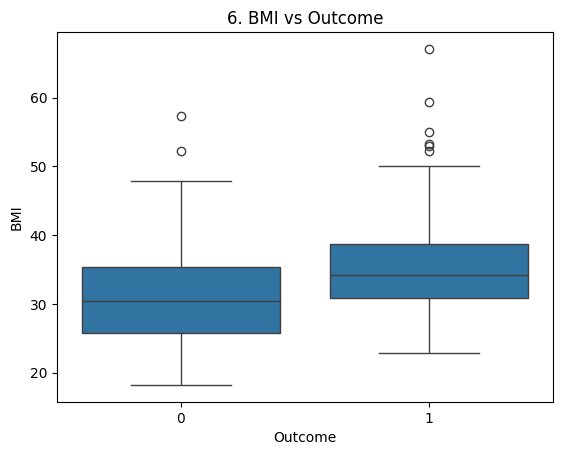

In [12]:
# 3. Glucose Distribution
sns.histplot(df['Glucose'], kde=True)
plt.title("3. Glucose Distribution")
plt.show()

# 4. BMI Distribution
sns.histplot(df['BMI'], kde=True)
plt.title("4. BMI Distribution")
plt.show()

# 5. Boxplot (Glucose vs Outcome)
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("5. Glucose vs Outcome")
plt.show()

# 6. Boxplot (BMI vs Outcome)
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("6. BMI vs Outcome")
plt.show()

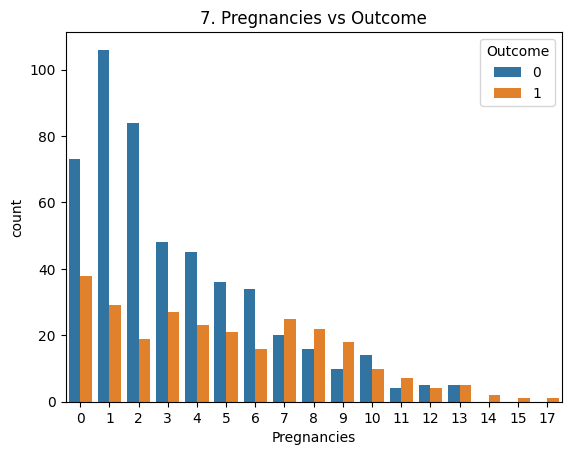

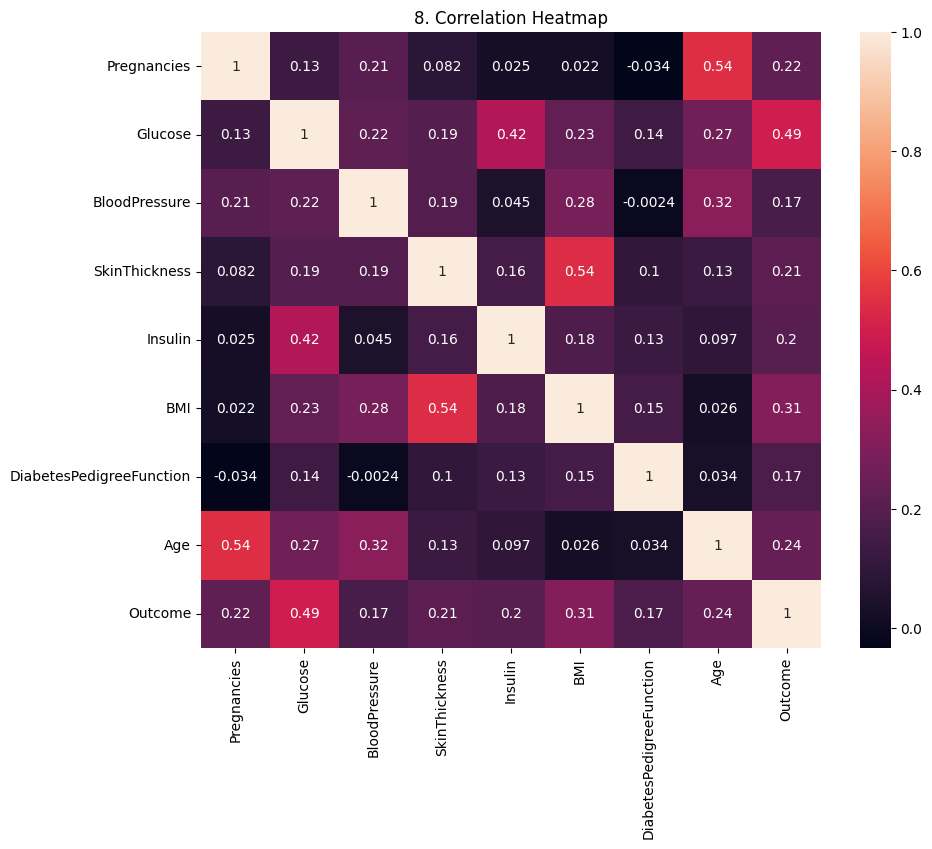

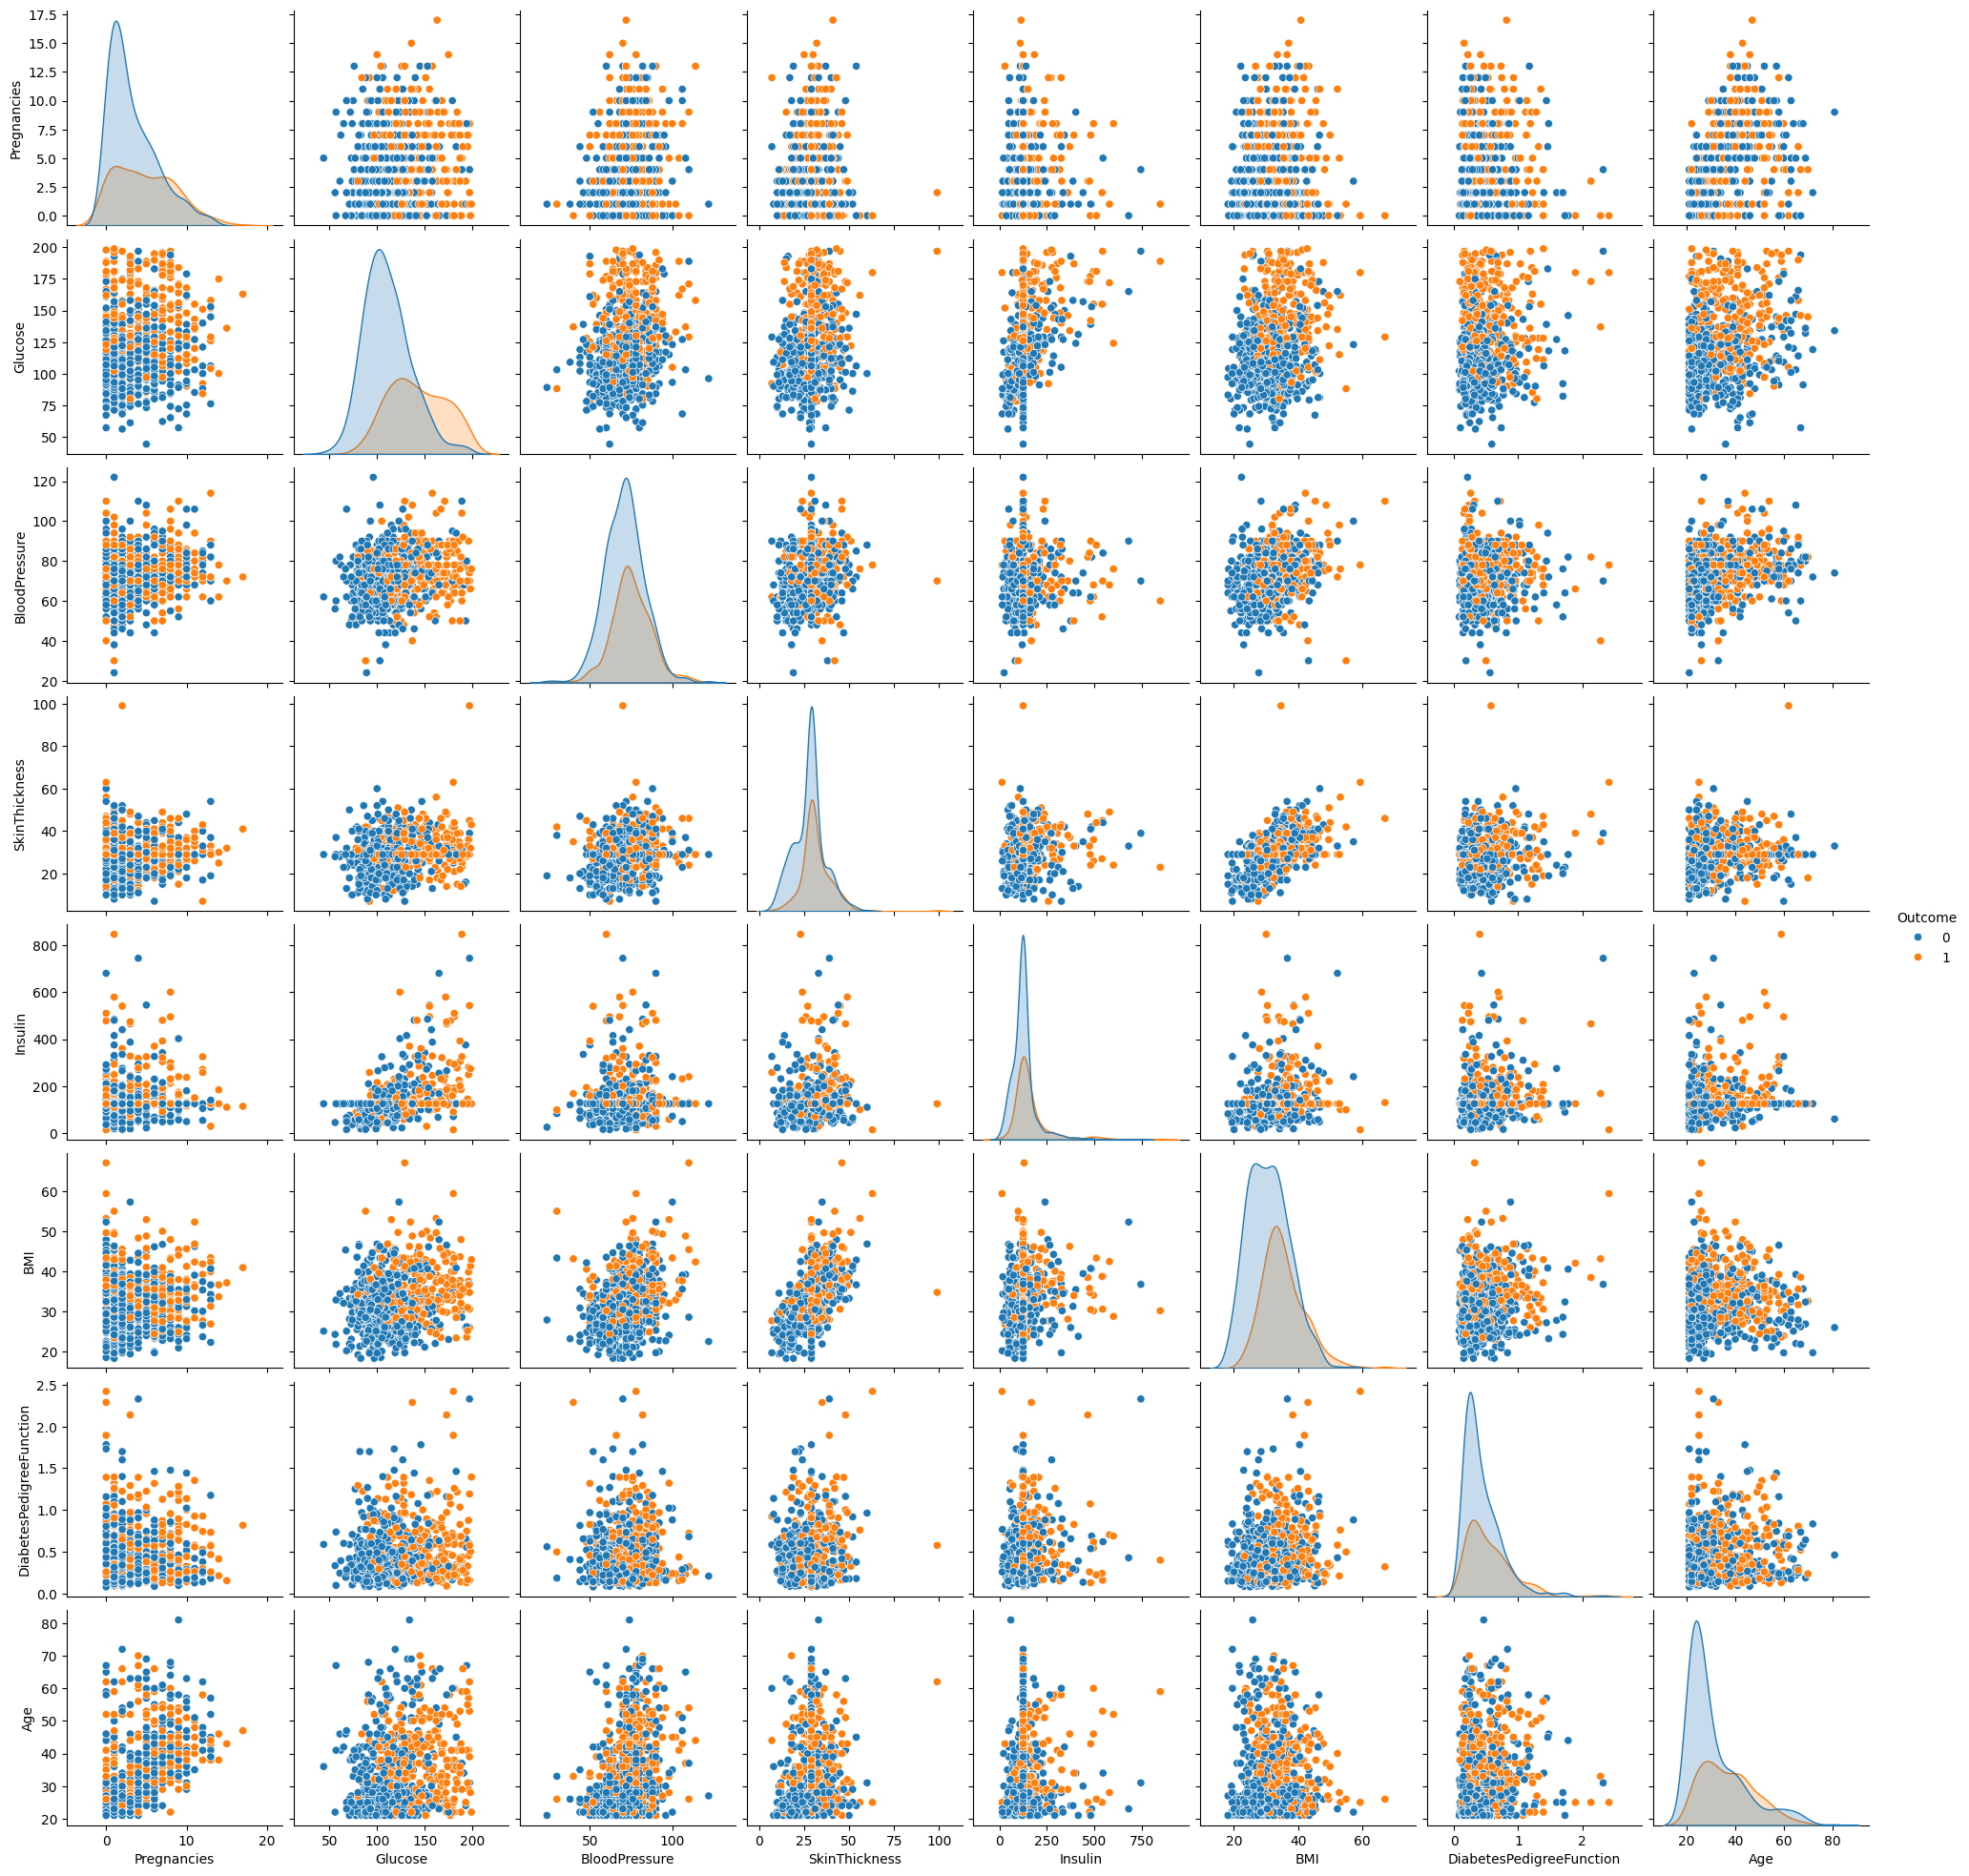

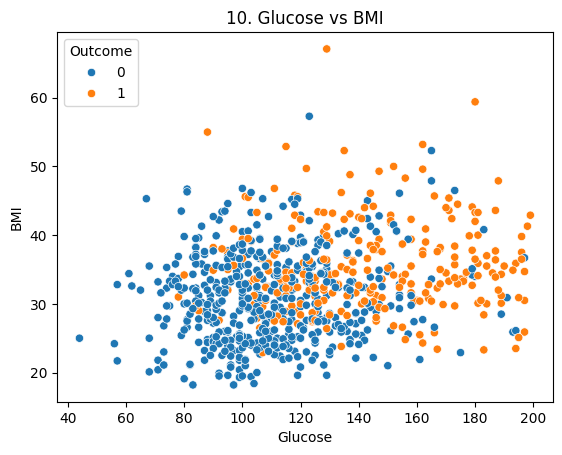

In [13]:
# 7. Pregnancies vs Outcome
sns.countplot(x='Pregnancies', hue='Outcome', data=df)
plt.title("7. Pregnancies vs Outcome")
plt.show()

# 8. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("8. Correlation Heatmap")
plt.show()

# 9. Pairplot
sns.pairplot(df, hue='Outcome')
plt.show()

# 10. Scatter Plot (Glucose vs BMI)
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("10. Glucose vs BMI")
plt.show()

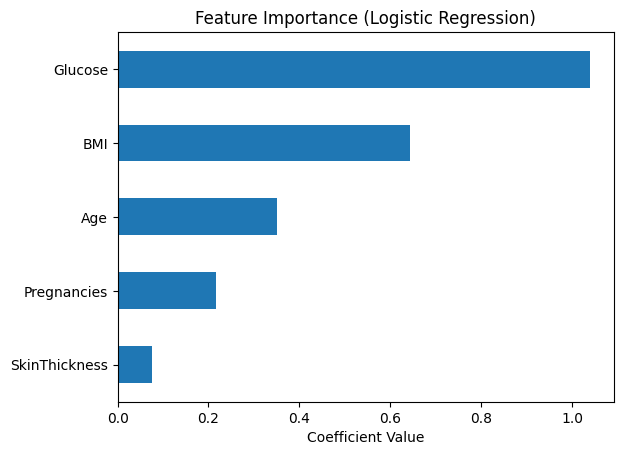

In [17]:
# feature importance (logistic)

importance = log_model.coef_[0]

feature_importance = pd.Series(importance, index = X.columns)
feature_importance = feature_importance.sort_values()

plt.figure()
feature_importance.plot(kind = 'barh')
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.show()



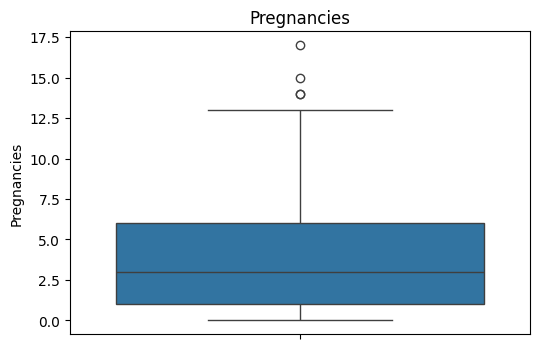

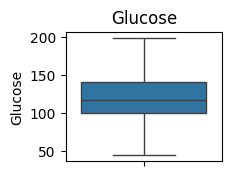

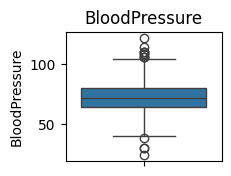

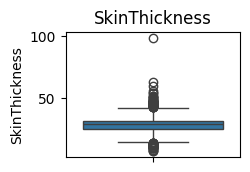

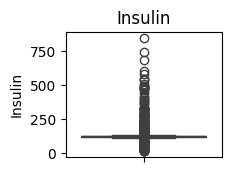

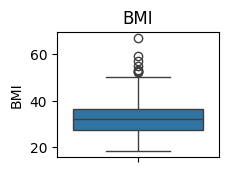

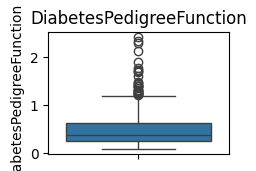

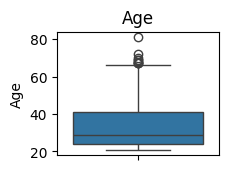

In [21]:
# outlier detection

plt.figure(figsize = (15,10))

for i,col in enumerate(df.columns[:-1], 1):
  plt.subplot(3,3,i)
  sns.boxplot(y=df[col])
  plt.title(f"{col}")

  plt.tight_layout()
  plt.show()


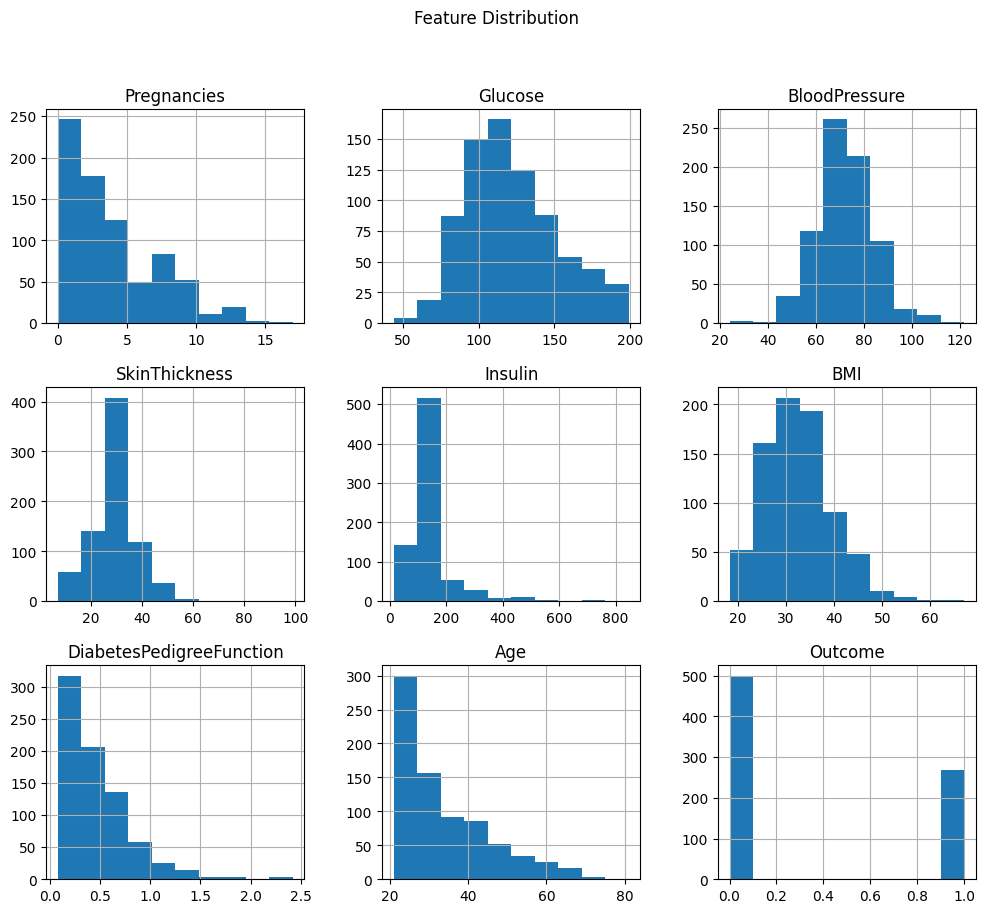

In [22]:
# distribution grid

df.hist(figsize=(12,10))
plt.suptitle("Feature Distribution")
plt.show()

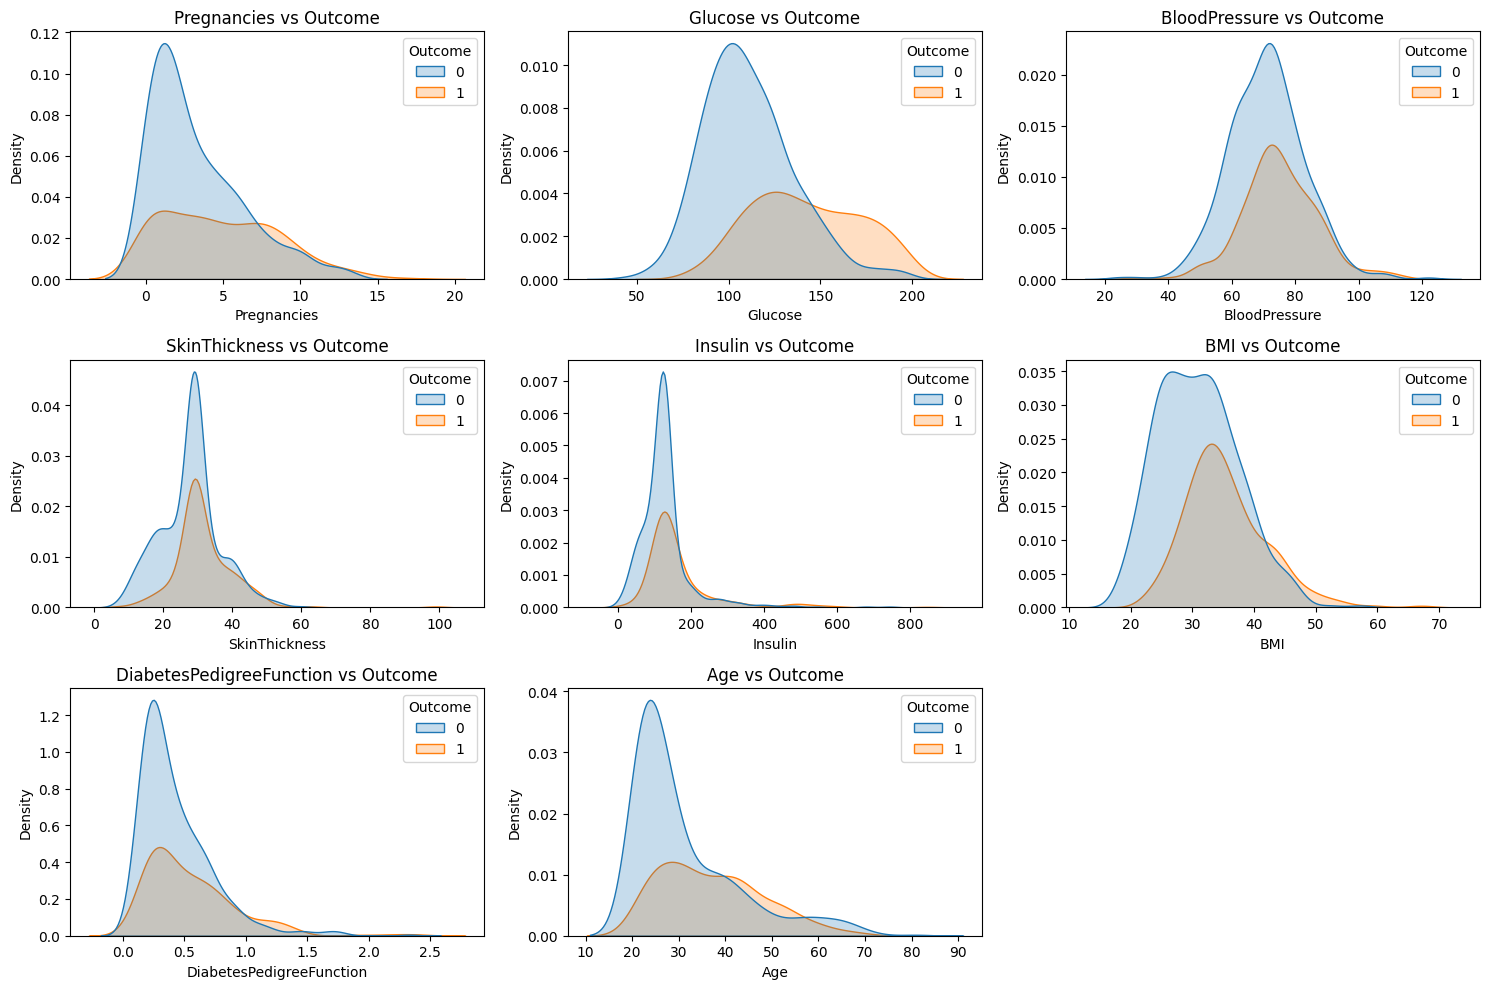

In [23]:
# kde grid (by target)

features = df.columns[:-1]

plt.figure(figsize=(15,10))

for i, col in enumerate(features,1):
  plt.subplot(3,3,i)
  sns.kdeplot(data=df, x=col, hue='Outcome', fill=True)
  plt.title(f"{col} vs Outcome")

plt.tight_layout()
plt.show()

In [28]:
# outlier removal (iqr) inter quartile range

def remove_outliers(df):
  df_out = df.copy()

  for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_out = df_out[(df_out[col] >= lower) & (df_out[col] <= upper)]

  return df_out

df_clean = remove_outliers(df)
print("Shape after outlier removal:", df_clean.shape)

Shape after outlier removal: (375, 9)


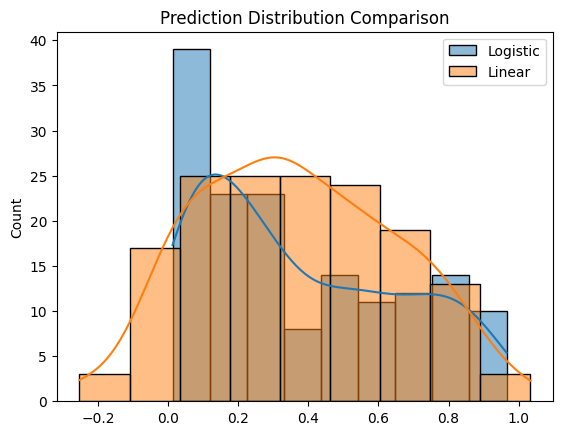

In [29]:
# compare prediction distribution

plt.figure()
sns.histplot(y_prob_log, label="Logistic", kde=True)
sns.histplot(y_prob_lin, label="Linear", kde = True)
plt.legend()
plt.title("Prediction Distribution Comparison")
plt.show()